#Limit Calculator

A simple limit calculator to determine how much product yeild can be derived from a feedstock, considering only the chemical formula of feedstock and product and assumming 100% conversion efficiency.


In [1]:
import pandas as pd
import matplotlib.pyplot 

In [2]:
# Degree of reduction
def degree_of_reduction (carbon, hydrogen, oxygen, nitrogen):
    """degree of reduction is the number of electrons available per carbon atom (gamma)
    formula is: gamme = (4*C + H - 2*O -3*N)/C"""

    electrons = 4*carbon + hydrogen - 2*oxygen - 3*nitrogen
    return electrons/carbon


In [3]:
#glucose C6H12O6 and methane CH4
print('glucose:', degree_of_reduction (6, 12, 6, 0))
print('methane:', degree_of_reduction (1, 4, 0, 0))


glucose: 4.0
methane: 8.0


In [4]:
def is_close (a, b, tolerance=0.001): 
    return abs (a -b) < tolerance 

#glucose C6H12O6 -> 4, methane CH4 -> 8, biomass CH1.8O0.5N0.2 -> 4.2
assert is_close(degree_of_reduction (6, 12, 6, 0), 4.0)
assert is_close(degree_of_reduction(1,4,0,0), 8.0)
assert is_close(degree_of_reduction(1,1.8,0.5,0.2), 4.2)
print('Tests passed')

Tests passed


# Max product yield 
The max product yeild of one Carbon mole of a feestock is determined by: 
- the number of carbon available (1 C-mol of product per C-mol of feedstock)
- electrons the carbon carries (gamma_feedstock/gamma_product) 

In [5]:
def max_yield (gamma_feedstock, gamma_product): 
    """Maximum C-Mol of product per C-mol of feedstock"""
    return min (1.0, gamma_feedstock/gamma_product)

In [6]:
print ('glucose -> ethanol:', (round(max_yield(4,6), 3)))
print ('methane -> biomass:', (round(max_yield (8,4.2), 3)))

glucose -> ethanol: 0.667
methane -> biomass: 1.0


In [7]:
#glucose (4) -> ethanol (6): the product is more reduced (more electrons than the feedstock) hence the amt of electrons determine the limit 
assert is_close (max_yield (4, 6), 0.667)
#methane (8) -> biomass (4.2): the feedstock is more reduced (more electrons than the product) hence the amt of carbon sets the limit
assert is_close (max_yield (8, 4.2), 1.0)

print('Yield tests passed')

Yield tests passed


In [8]:
# feedstocks and products 
feedstocks = pd.read_csv('data/feedstocks.csv')

products = pd.read_csv('data/products.csv')


In [16]:
# degree of reduction of every feedstock
feedstock_gammas = []
for i in range(feedstocks.shape[0]):
    gamma = degree_of_reduction(feedstocks.loc[i, 'C'],
                                feedstocks.loc[i, 'H'],
                                feedstocks.loc[i, 'O'],
                                feedstocks.loc[i, 'N'])
    feedstock_gammas.append(round(gamma, 2))

feedstocks['gamma'] = feedstock_gammas
feedstocks


,name,C,H,O,N,gamma
0,formate,1,2,2,0,2.00
1,acetate,2,4,2,0,4.00
2,glucose,6,12,6,0,4.00
3,glycerol,3,8,3,0,4.67
4,methanol,1,4,1,0,6.00
5,methane,1,4,0,0,8.00


In [17]:
# degree of reduction of every product
product_gammas = []
for j in range(products.shape[0]):
    gamma = degree_of_reduction(products.loc[j, 'C'],
                                products.loc[j, 'H'],
                                products.loc[j, 'O'],
                                products.loc[j, 'N'])
    product_gammas.append(round(gamma, 2))

products['gamma'] = product_gammas
products

,name,C,H,O,N,gamma
0,lactate,3,6.0,3.0,0.0,4.0
1,biomass,1,1.8,0.5,0.2,4.2
2,PHB,4,6.0,2.0,0.0,4.5
3,ethanol,2,6.0,1.0,0.0,6.0


In [ ]:
#determine number of feedstock-product pairs
feedstock_column =[]
product_column = []
yield_column = []

for i in range (feedstocks.shape[0]): 
    gamma_feedstock = degree_of_reduction (feedstocks.loc[i, 'C'], 
                                           feedstocks.loc[i, 'H'],
                                           feedstocks.loc[i, 'O'],
                                           feedstocks.loc[i, 'N'])

    for j in range (products.shape[0]):
        gamma_product = degree_of_reduction (products.loc[j, 'C'], 
                                             products.loc[j, 'H'], 
                                             products.loc[j, 'O'], 
                                             products.loc[j, 'N'])

        feedstock_column.append(feedstocks.loc [i, 'name'])
        product_column.append (products.loc[j, 'name'])
        yield_column.append(round(max_yield(gamma_feedstock, gamma_product), 3)) 

print ('Calculated', len (yield_column), 'pairs')

Calculated 24 pairs


In [11]:
results = pd.DataFrame({'feedstock': feedstock_column,
                       'product': product_column,
                       'max_yield': yield_column})
results.to_csv('results/limits.csv', index=False)
results.head(7)

,feedstock,product,max_yield
0,formate,lactate,0.500
1,formate,biomass,0.476
2,formate,PHB,0.444
3,formate,ethanol,0.333
4,acetate,lactate,1.000
5,acetate,biomass,0.952
6,acetate,PHB,0.889


In [12]:
#finding the best pairs ie pairs that give yield of 1.00
top = results['max_yield'].max()
best = results[results['max_yield'] == top]

print('Highest possible yield:', top)
print(len(best), 'pairs reach it')
best


Highest possible yield: 1.0
13 pairs reach it


,feedstock,product,max_yield
4,acetate,lactate,1.0
8,glucose,lactate,1.0
12,glycerol,lactate,1.0
13,glycerol,biomass,1.0
14,glycerol,PHB,1.0
16,methanol,lactate,1.0
17,methanol,biomass,1.0
18,methanol,PHB,1.0
19,methanol,ethanol,1.0
20,methane,lactate,1.0


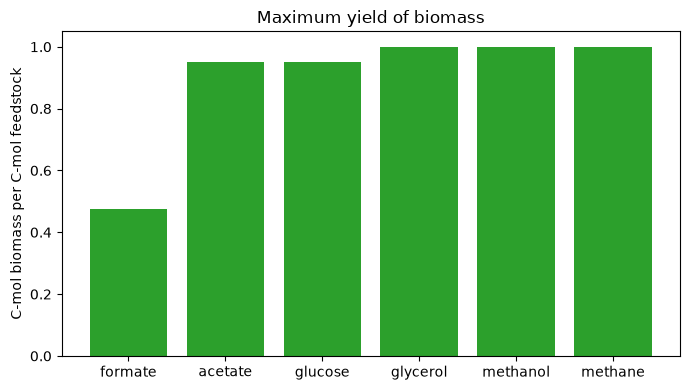

In [13]:
#Plot: making lactate from each feedstock 

biomass = results.query('product == "biomass"')

fig = matplotlib.pyplot.figure(figsize=(7.0, 4.0))
axes = fig.add_subplot (1, 1, 1)
axes.bar(biomass['feedstock'], biomass ['max_yield'], color='tab:green')
axes.set_ylabel('C-mol biomass per C-mol feedstock')
axes.set_title('Maximum yield of biomass')
fig.tight_layout()
matplotlib.pyplot.savefig('results/biomass_yield.png')
matplotlib.pyplot.show()


- Glycerol, methanol and methane are the best candidates for making lactate. 
- Formate gives the lowest yields, because it carries only 2 electrons per carbon.
- Glucose and acetate give identical results, because both have a degree of reduction of 4.